In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# Load dataset
df = pd.read_excel("Diabetes Dataset.xlsx")

y = df["diabetes"]
X = df.drop(columns=["diabetes"])
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Same split as Phase 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load your saved tuned model (pipeline)
best_rf = load("tuned_random_forest_pipeline.joblib")

# Preds and probabilities
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

This loads our Diabetes Dataset and Tuned Model

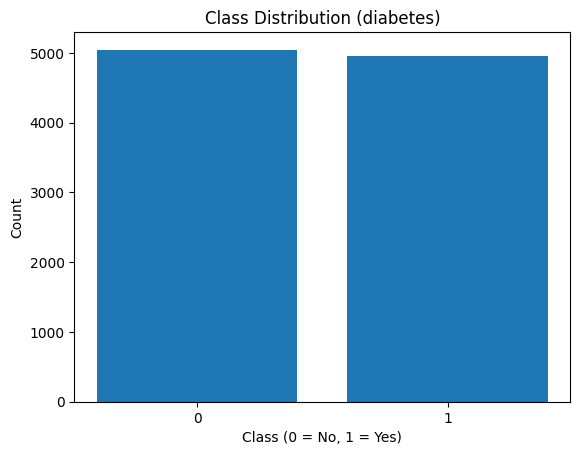

In [4]:
counts = y.value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (diabetes)")
plt.xlabel("Class (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

This bar chart helps us check whether the dataset is balanced or imbalanced.
This is important because class imbalance can affect model evaluation and may require metrics like Precision, Recall, and F1-score.

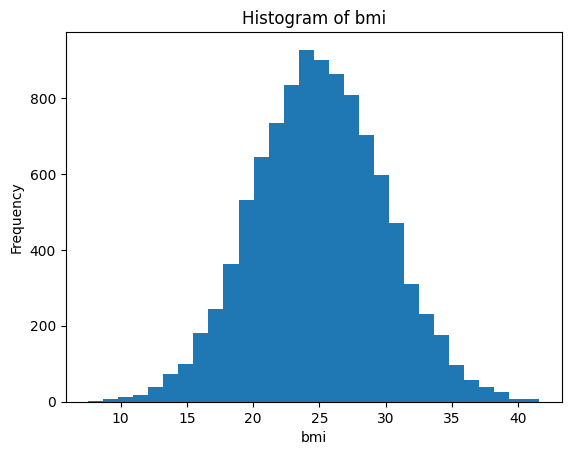

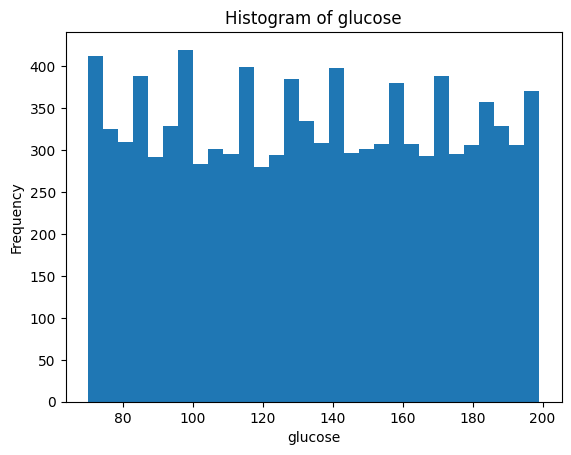

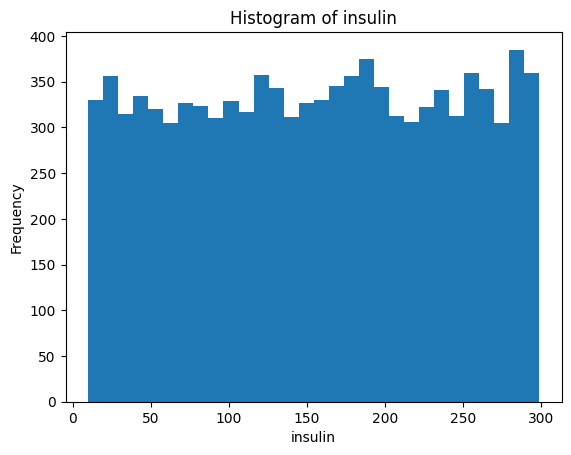

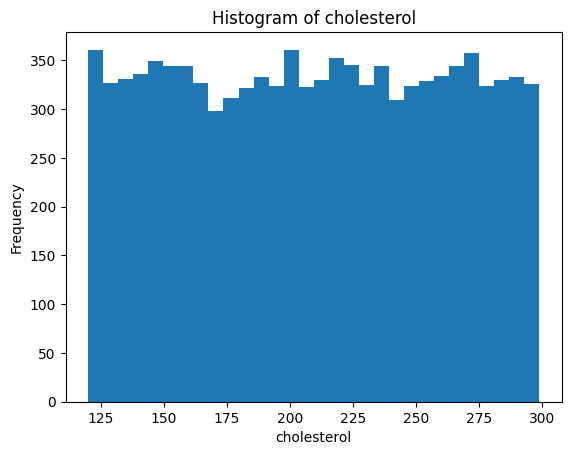

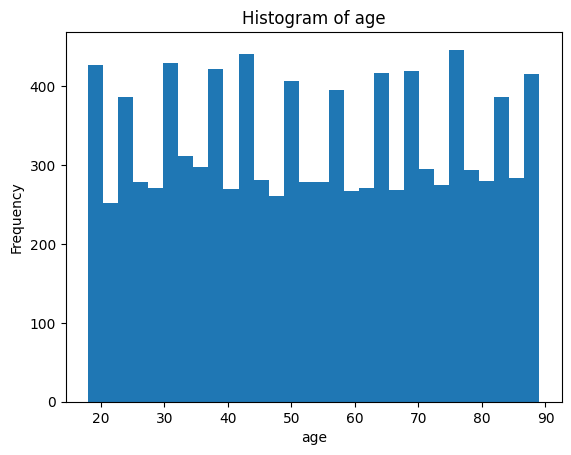

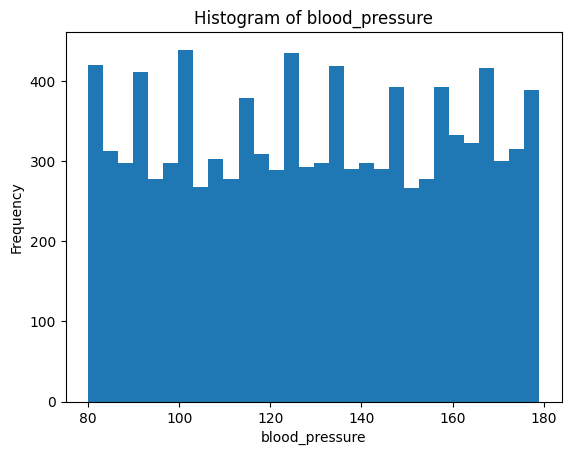

In [5]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Choose 6 columns to visualize (edit if you want)
cols_to_plot = [c for c in ["bmi","glucose","insulin","cholesterol","age","blood_pressure"] if c in numeric_cols]

for col in cols_to_plot:
    plt.figure()
    plt.hist(X[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

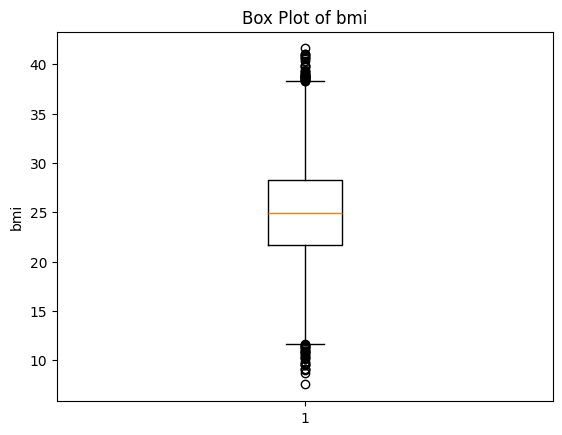

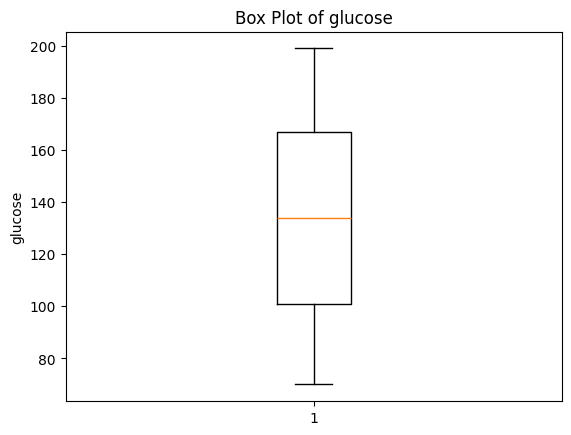

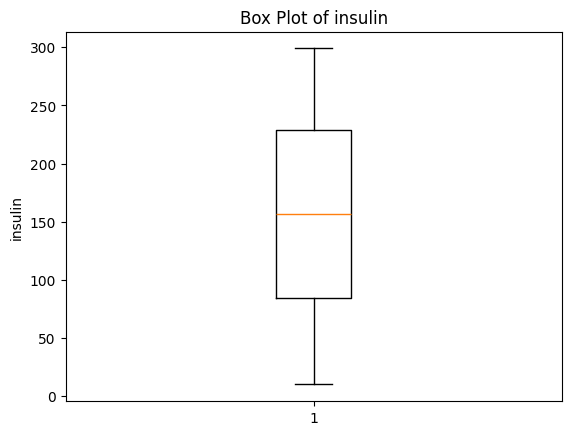

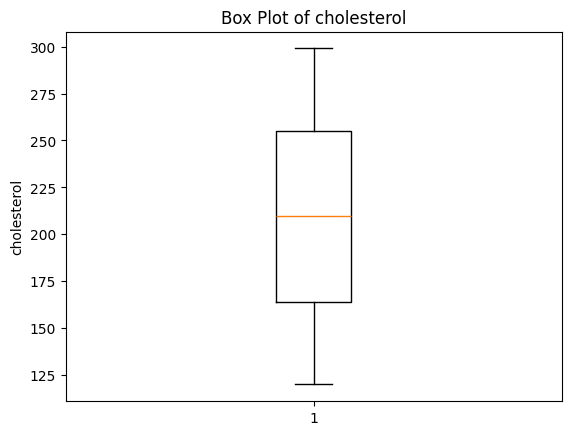

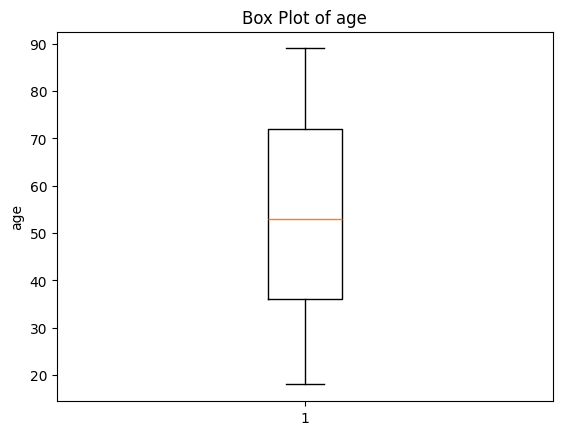

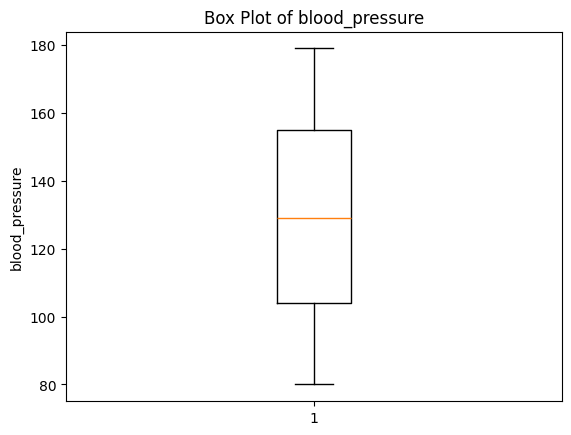

In [6]:
for col in cols_to_plot:
    plt.figure()
    plt.boxplot(X[col].dropna(), vert=True)
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

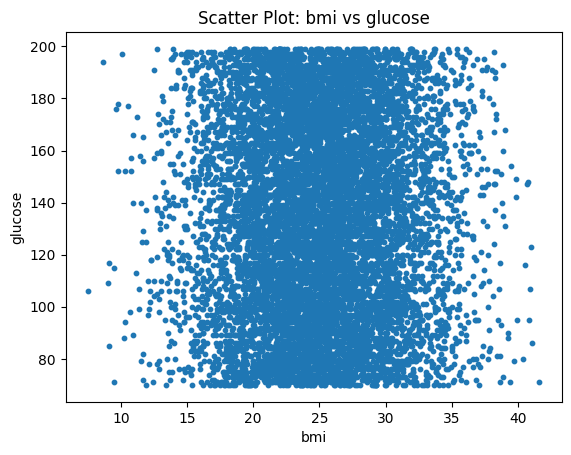

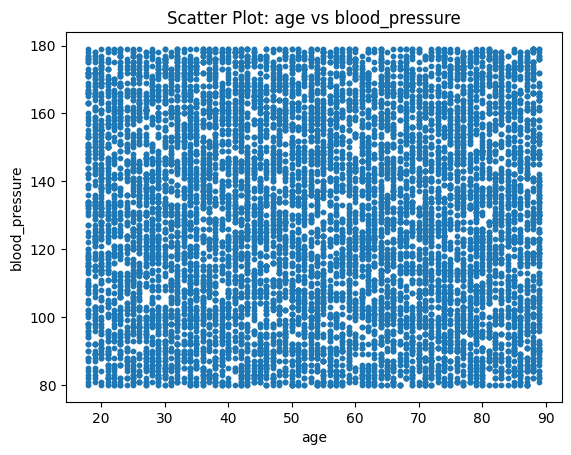

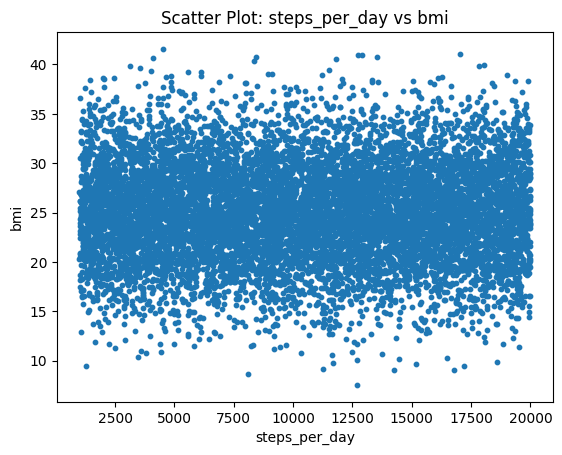

In [7]:
pairs = [("bmi","glucose"), ("age","blood_pressure"), ("steps_per_day","bmi")]

for a, b in pairs:
    if a in X.columns and b in X.columns:
        plt.figure()
        plt.scatter(X[a], X[b], s=10)
        plt.title(f"Scatter Plot: {a} vs {b}")
        plt.xlabel(a)
        plt.ylabel(b)
        plt.show()

The BMI histogram looks close to a bell shape. Most values are concentrated around the mid-20s, and fewer people appear in very low or very high BMI ranges. This means BMI has a “common” middle range and fewer extreme values. There are small tails on both sides, which suggests some outliers but not too many.

The glucose histogram looks almost flat from about 70 to 200. This means glucose values are spread out fairly evenly across the whole range, and there is no strong peak.

The insulin histogram also looks almost uniform, meaning the values are spread across the range without one clear most common region. There is no strong distortion.

The cholesterol histogram appears fairly uniform across roughly 120 to 300. There are small ups and downs, but overall there is no strong peak. This means cholesterol values are fairly evenly represented across the range.

The age histogram looks mostly uniform across about 18 to 90. That means the dataset includes many ages, and no single age group dominates strongly. There is no clear distortion.

The blood pressure histogram also looks mostly uniform, roughly from 80 to 180. This indicates blood pressure values are spread evenly across this range, with no strong concentration around a specific value.

Overall, BMI looks more like real-world data because it has a bell-shaped distribution, while glucose, insulin, cholesterol, age, and blood pressure look more evenly distributed. When features are uniform, it can sometimes be harder for the model to find strong “natural patterns,” which may partly explain why our model performance stayed around ~0.50.

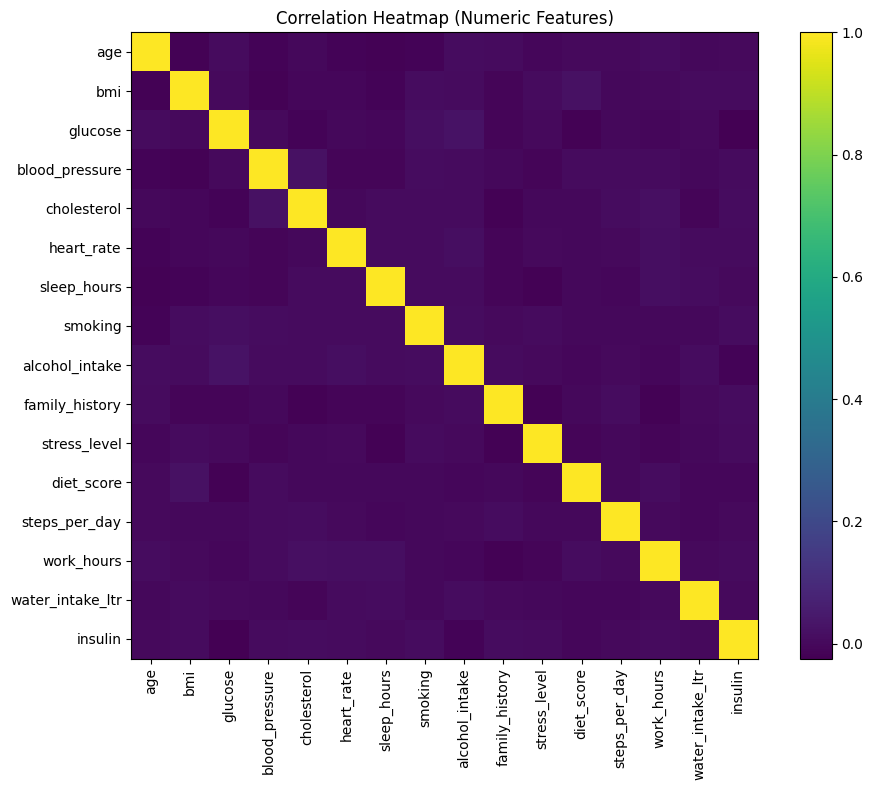

In [8]:
corr = X[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

This correlation heatmap shows the linear relationship between each pair of numeric features in the dataset. The bright diagonal line appears because each feature is perfectly correlated with itself. Most cells outside the diagonal are dark, meaning the correlations are close to 0, which means that most numeric variables have weak or no strong linear relationship with each other. This shows low redundancy among features and that any patterns in the data may not be strongly linear.

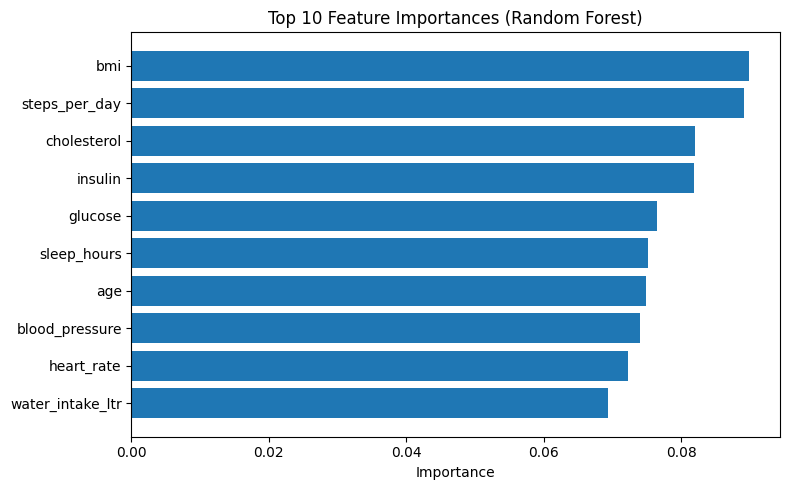

Top 10 Feature Importances:
         feature  importance
             bmi    0.089887
   steps_per_day    0.089151
     cholesterol    0.082058
         insulin    0.081867
         glucose    0.076466
     sleep_hours    0.075134
             age    0.074829
  blood_pressure    0.074001
      heart_rate    0.072283
water_intake_ltr    0.069284


In [11]:
# Extract feature names from pipeline (after encoding)
prep = best_rf.named_steps["prep"]
model = best_rf.named_steps["model"]

cat_transformer = prep.named_transformers_["cat"]
num_features = prep.transformers_[1][2]
cat_features = prep.transformers_[0][2]

cat_feature_names = cat_transformer.get_feature_names_out(cat_features)
all_feature_names = list(cat_feature_names) + list(num_features)

importances = model.feature_importances_

import pandas as pd
feat_imp = pd.DataFrame({"feature": all_feature_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

top10 = feat_imp.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(top10["feature"], top10["importance"])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 Feature Importances:")
print(feat_imp.head(10).to_string(index=False))

This bar chart shows the 10 most important features used by the tuned Random Forest model when predicting diabetes. Features with longer bars have higher importance, meaning the model relied on them more often to make decisions across its trees. In our results, BMI and steps_per_day had the highest importance, followed by cholesterol, insulin, and glucose, suggesting these variables had the strongest influence on the model’s predictions compared to the other features.

<Figure size 640x480 with 0 Axes>

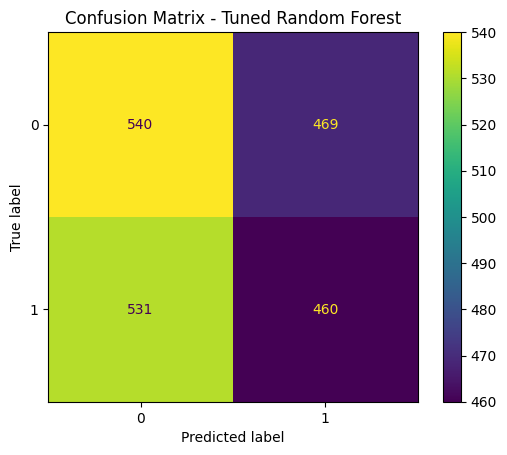

In [12]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

The model correctly predicted 540 non-diabetic cases and 460 diabetic cases. However, it also misclassified 469 non-diabetic cases as diabetic and 531 diabetic cases as non-diabetic. Overall, the errors are still high, meaning the model has difficulty clearly separating the two classes.

<Figure size 640x480 with 0 Axes>

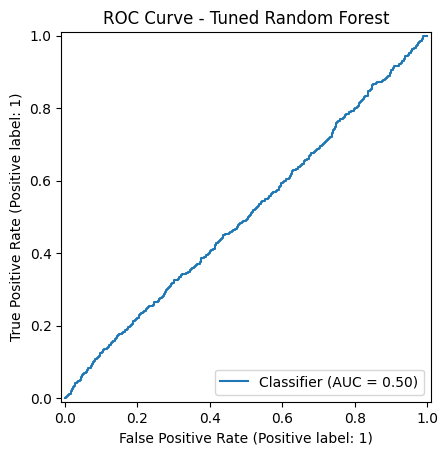

In [13]:
plt.figure()
RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

This ROC curve shows the tradeoff between the True Positive Rate and the False Positive Rate at different probability thresholds for the tuned Random Forest. Ideally, the curve should be closer to the top-left corner, which indicates strong class separation. In our case, the curve is close to the diagonal line and the Area Under Curve is 0.50, meaning the model’s ability to distinguish between diabetic and non-diabetic cases is about the same as random guessing.

<Figure size 640x480 with 0 Axes>

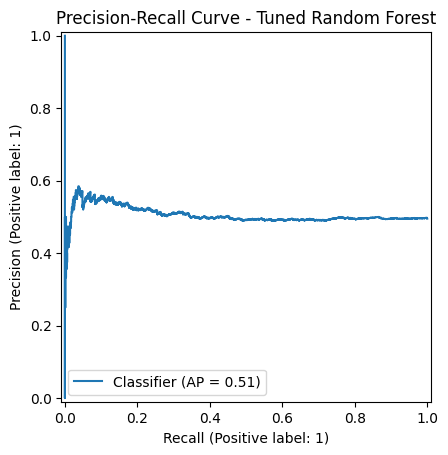

In [14]:
plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, rf_proba)
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.show()

The curve shows the relationship between Precision of how many predicted diabetics are truly diabetic and Recall of how many actual diabetics the model correctly finds for different probability thresholds. A better model would keep precision high even as recall increases. In our graph, precision stays around 0.50 for most recall values, and the Average Precision (AP) is about 0.51, which is only slightly above chance. This indicates the model does not strongly separate diabetic cases from non-diabetic cases when using probability thresholds.

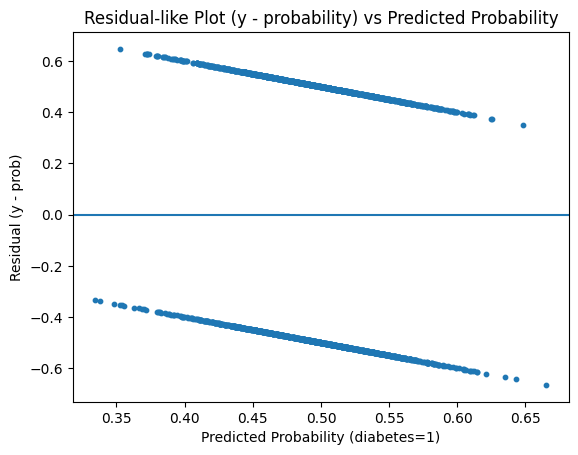

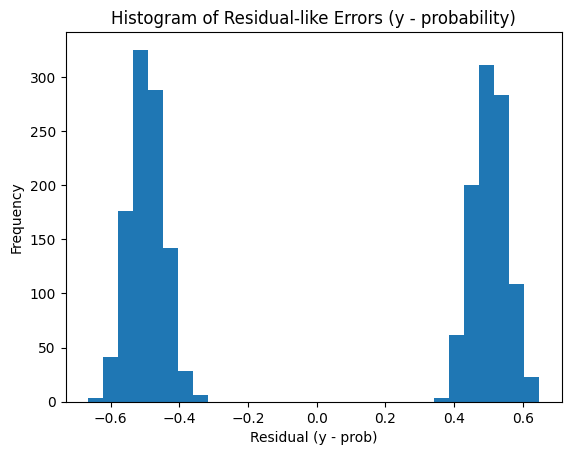

In [15]:
residual = y_test.values - rf_proba

plt.figure()
plt.scatter(rf_proba, residual, s=10)
plt.title("Residual-like Plot (y - probability) vs Predicted Probability")
plt.xlabel("Predicted Probability (diabetes=1)")
plt.ylabel("Residual (y - prob)")
plt.axhline(0)
plt.show()

plt.figure()
plt.hist(residual, bins=30)
plt.title("Histogram of Residual-like Errors (y - probability)")
plt.xlabel("Residual (y - prob)")
plt.ylabel("Frequency")
plt.show()

The scatter plot shows two main bands: one positive band when the true class is 1 and one negative band when the true class is 0, because residuals for class 1 are 1 − 𝑝 1−p and for class 0 are 0 − 𝑝 0−p. In our plot, most predicted probabilities are clustered around roughly 0.35 to 0.65, and the errors are not centered tightly around 0, which suggests the model is often uncertain and does not assign very confident probabilities. The histogram shows two separated groups of residuals, reflecting the two classes, and indicates that many predictions still produce sizable errors, meaning the probability estimates are not very accurate or well-separated.